# Handling Imbalanced Dataset Using SMOTE (Synthetic Minority Over-sampling Technique)

---

# 1. What problem does it solve?

**SMOTE (Synthetic Minority Over-sampling Technique)** solves the problem of **class imbalance** by creating **new synthetic samples** for the minority class instead of simply duplicating existing ones.

Example (Before SMOTE):

| Class      | Count |
| ---------- | ----: |
| Legitimate | 9,000 |
| Fraud      | 1,000 |

A model trained on this dataset is likely to favor the majority class.

Example (After SMOTE):

| Class      | Count |
| ---------- | ----: |
| Legitimate | 9,000 |
| Fraud      | 9,000 |

The model now has a more balanced dataset to learn from.

### Problems SMOTE addresses

* Poor Recall for minority class
* Biased predictions toward majority class
* Overfitting caused by simple duplication (Random Over-Sampling)
* Better learning of minority class decision boundaries

---

# 2. Why is SMOTE needed?

Random Over-Sampling simply copies existing minority samples.

Example:

Original minority samples:

```text
A
B
C
```

After Random Over-Sampling:

```text
A
B
C
A
A
B
C
```

The model may memorize these duplicates, leading to **overfitting**.

SMOTE instead creates **new synthetic points** between existing minority samples.

Example:

Original:

```text
A -------- B
```

SMOTE creates:

```text
A ---- X ---- B
```

where **X** is a newly generated synthetic sample.

---

# 3. When should I use SMOTE?

Use SMOTE when:

* The dataset is **imbalanced**.
* The problem is **classification**.
* The minority class has enough samples to learn meaningful patterns.
* You want to improve Recall and F1-score.
* Random Over-Sampling causes overfitting.

Common applications:

* Fraud detection
* Disease diagnosis
* Spam detection
* Intrusion detection
* Customer churn prediction

---

# 4. When should I NOT use SMOTE?

Do **not** use SMOTE:

* For regression problems.
* On the test set or validation set.
* Before train-test splitting (causes data leakage).
* When the minority class has very few samples (synthetic points may be unrealistic).
* When features are mostly categorical (basic SMOTE is designed for continuous numerical features; variants like **SMOTENC** are better for mixed data).

---

# 5. Types of SMOTE

## A. Regular SMOTE

Creates synthetic samples between a minority sample and one of its nearest minority neighbors.

Most commonly used.

---

## B. Borderline-SMOTE

Generates synthetic samples mainly near the decision boundary, where misclassification is more likely.

Useful when classes overlap.

---

## C. SVMSMOTE

Uses a Support Vector Machine to identify boundary regions before generating synthetic samples.

Good for complex class boundaries.

---

## D. KMeans-SMOTE

Clusters the data first and then generates synthetic samples within clusters.

Useful for complex minority distributions.

---

## E. SMOTENC

Designed for datasets with **both numerical and categorical** features.

---

# 6. How does SMOTE work?

Suppose these are minority-class points:

```text
A(2,2)

B(4,4)
```

SMOTE:

1. Selects a minority sample.
2. Finds its *k* nearest minority neighbors.
3. Randomly selects one neighbor.
4. Creates a new point somewhere between them.

Formula:

[
\text{New Sample} = x_i + \lambda (x_{neighbor} - x_i)
]

where:

* (x_i) = original minority sample
* (x_{neighbor}) = one of its nearest minority neighbors
* (\lambda) = random number between 0 and 1

Example:

A = (2,2)

B = (4,4)

If λ = 0.5

New sample:

(3,3)

---

# 7. Decision Flow

```text
Classification Problem?

│

└── Yes

      │

      ▼

Dataset Imbalanced?

│

├── No → No SMOTE Needed

└── Yes

      │

      ▼

Minority Class Important?

├── No → Train Normally

└── Yes

      │

      ▼

Mostly Numerical Features?

├── Yes → Use SMOTE

└── No

      │

      ▼

Mixed Numerical + Categorical?

├── Yes → Use SMOTENC

└── Mostly Categorical → Consider other approaches
```

---

# 8. Code

## Install

```bash
pip install imbalanced-learn
```

---

## Basic Example

```python
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X_train, y_train)
```

---

## Complete Example

```python
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    stratify=y,
    random_state=42
)

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)
```

> **Important:** Apply SMOTE **only to the training data**. Leave the test data unchanged so model evaluation reflects real-world performance.

---

# 9. Pros & Cons

| Pros                                                 | Cons                                                   |
| ---------------------------------------------------- | ------------------------------------------------------ |
| Reduces class imbalance                              | Can create unrealistic synthetic samples               |
| Better than simple duplication                       | May amplify noise if minority data is noisy            |
| Often improves Recall and F1-score                   | Increases training time                                |
| Reduces overfitting compared to Random Over-Sampling | Can blur class boundaries when classes overlap heavily |

---

# 10. Algorithm Compatibility

| Algorithm           | Works Well with SMOTE?                       |
| ------------------- | -------------------------------------------- |
| Logistic Regression | ✅                                            |
| SVM                 | ✅                                            |
| KNN                 | ✅                                            |
| Decision Tree       | ✅                                            |
| Random Forest       | ✅                                            |
| XGBoost             | ✅ (compare with class weights)               |
| LightGBM            | ✅ (compare with built-in imbalance handling) |
| CatBoost            | ✅                                            |

> Even for algorithms that support class weights, it's often worth comparing results with and without SMOTE to see which performs better on your specific dataset.

---

# 11. Interview Questions

### Basic

* What is SMOTE?
* Why is SMOTE preferred over Random Over-Sampling?
* Is SMOTE used for classification or regression?

### Intermediate

* How does SMOTE generate new samples?
* Why shouldn't SMOTE be applied before train-test splitting?
* What is the role of nearest neighbors in SMOTE?

### Advanced

* Difference between SMOTE and Random Over-Sampling?
* Difference between SMOTE and ADASYN?
* What are the limitations of SMOTE?
* When would you use SMOTENC instead of SMOTE?

---

# 12. Common Mistakes

❌ Applying SMOTE before train-test splitting (data leakage).

❌ Applying SMOTE to the test set.

❌ Using SMOTE for regression problems.

❌ Using SMOTE when the minority class has extremely few examples.

❌ Assuming SMOTE always improves performance without validating with appropriate metrics.

❌ Ignoring feature scaling for distance-based algorithms (SMOTE relies on nearest neighbors).

---

# 13. Real-World Examples

### Banking

Fraud transactions are extremely rare.

SMOTE helps generate synthetic fraud examples so the model learns fraudulent patterns more effectively.

---

### Healthcare

A dataset contains far fewer patients with a rare disease than healthy patients.

SMOTE creates additional synthetic disease cases to improve disease detection.

---

### Cybersecurity

Most network traffic is normal, while attack traffic is limited.

SMOTE helps intrusion detection models better recognize attack patterns.

---

### Manufacturing

Defective products are much less common than non-defective ones.

SMOTE balances the training data, improving defect detection.

---

### Customer Churn

Only a small percentage of customers leave a service.

SMOTE helps the model identify characteristics of customers likely to churn.

---

# 14. Revision Box

```text
SMOTE (Synthetic Minority Over-sampling Technique)

✔ Used only for classification
✔ Solves class imbalance
✔ Creates synthetic minority samples
✔ Uses k-nearest neighbors
✔ Better than simply duplicating minority samples

Workflow:
Split Data
      ↓
Apply SMOTE on Training Set Only
      ↓
Train Model
      ↓
Evaluate on Original Test Set

Common Variants:
• SMOTE
• Borderline-SMOTE
• SVMSMOTE
• KMeans-SMOTE
• SMOTENC

Pros:
✔ Better Recall
✔ Better F1-Score
✔ Less overfitting than Random Over-Sampling

Avoid:
✘ Test set
✘ Regression
✘ Very small minority classes
✘ Before train-test split

Interview Tip:
SMOTE creates **new synthetic samples between existing minority-class points**—it does **not** simply duplicate existing records.
```


In [4]:
# What is SMOTE?

# Import the make_classification function from scikit-learn's datasets module
from sklearn.datasets import make_classification

In [7]:
# Generate a synthetic dataset for a classification task
make_classification

# See tha parameters it has...

<function sklearn.datasets._samples_generator.make_classification(n_samples=100, n_features=20, *, n_informative=2, n_redundant=2, n_repeated=0, n_classes=2, n_clusters_per_class=2, weights=None, flip_y=0.01, class_sep=1.0, hypercube=True, shift=0.0, scale=1.0, shuffle=True, random_state=None)>

In [24]:
# Generate a synthetic classification dataset and store the features in X and labels in y
X, y = make_classification(
    # Total number of data samples (rows) to generate
    n_samples=1000,

    # Number of redundant (duplicate/derived) features to generate
    n_redundant=0,

    # Total number of input features (columns)
    n_features=2,

    # Create one cluster for each class
    n_clusters_per_class=1,

    # Set the class distribution so that 90% of samples belong to one class
    weights=[0.90],

    # Set a fixed random seed for reproducible results
    random_state=12
)

# X -> Independent variable(s) / Input features (used to make predictions)
# y -> Dependent variable / Target label (the value to be predicted)

In [25]:
import pandas as pd

In [26]:
# Create a DataFrame named 'df1' from the feature matrix X with column names 'f1' and 'f2'
df1 = pd.DataFrame(X, columns=['f1', 'f2'])

# Create a DataFrame named 'df2' from the target variable y with the column name 'target'
df2 = pd.DataFrame(y, columns=['target'])

In [27]:
# Concatenate the feature DataFrame (df1) and target DataFrame (df2) column-wise to create a single DataFrame
final_df = pd.concat([df1, df2], axis=1)

# Display the first 5 rows of the combined DataFrame
final_df.head()

,f1,f2,target
0,-0.762898,-0.706808,0
1,-1.075436,-1.051162,0
2,-0.610115,-0.909802,0
3,-2.023284,-0.428945,1
4,-0.812921,-1.316206,0


In [28]:
# Count the number of occurrences of each unique value in the 'target' column
final_df['target'].value_counts()

# as said above, 92% be in majority of 100.

,count
target,
0,900
1,100


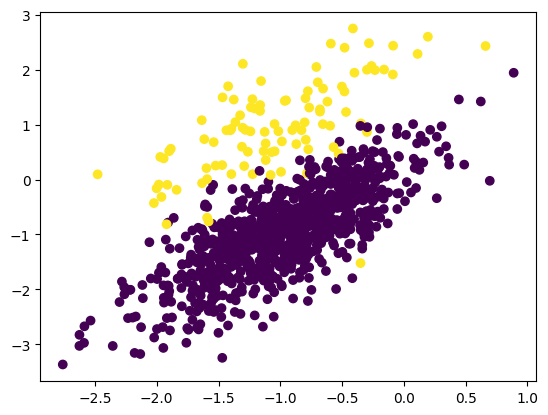

In [30]:
# Import the pyplot module from Matplotlib for creating plots and visualizations
import matplotlib.pyplot as plt

# Create a scatter plot using 'f1' and 'f2', where each point's color represents its target class
plt.scatter(final_df['f1'], final_df['f2'], c=final_df['target'])

In [ ]:
# To use SMOTE, we will use : !pip install imblearn

In [33]:
!pip install imblearn

In [37]:
# Import the SMOTE class from the imbalanced-learn library to perform oversampling on the minority class
from imblearn.over_sampling import SMOTE

In [42]:
# Create a SMOTE object to perform oversampling on the minority class
oversample = SMOTE()

# Apply SMOTE to generate synthetic samples for the minority class and create a balanced dataset
X, y = oversample.fit_resample(final_df[['f1', 'f2']], final_df['target'])

In [39]:
X.shape

(1800, 2)

In [40]:
y.shape

(1800,)

In [41]:
# wrt y how many 0s i have?
y==0

,target
0,True
1,True
2,True
3,False
4,True
...,...
1795,False
1796,False
1797,False
1798,False


In [43]:
len(y[y==0])

900

In [44]:
len(y[y==1])

900

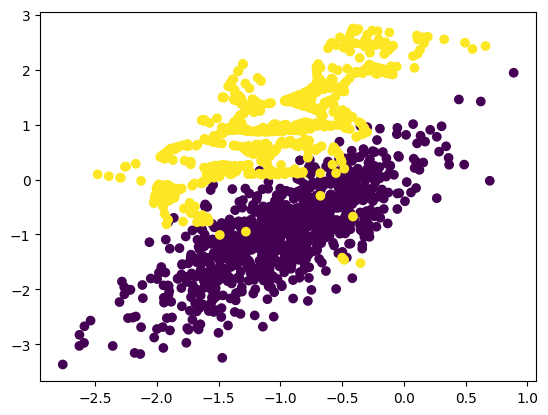

In [45]:
# Create a DataFrame from the resampled feature matrix X with column names 'f1' and 'f2'
df1 = pd.DataFrame(X, columns=['f1', 'f2'])

# Create a DataFrame from the resampled target variable y with the column name 'target'
df2 = pd.DataFrame(y, columns=['target'])

# Concatenate the feature and target DataFrames column-wise to create the final balanced dataset
oversample_df = pd.concat([df1, df2], axis=1)

# Create a scatter plot of the balanced dataset, coloring points according to their target class
plt.scatter(oversample_df['f1'], oversample_df['f2'], c=oversample_df['target'])

In [46]:
# Clearly, all the datapoints are increased, and are connected

SMOTE (**Synthetic Minority Over-sampling Technique**) balances an imbalanced dataset by **creating new synthetic (artificial) samples** for the minority class instead of simply duplicating existing ones.

Here's what happens behind the scenes.

### Step 1: Original imbalanced dataset

Suppose your dataset looks like this:

| f1 | f2 | target |
| -- | -- | ------ |
| 1  | 2  | 0      |
| 2  | 1  | 0      |
| 3  | 2  | 0      |
| 8  | 8  | 1      |
| 9  | 9  | 1      |

* Class **0** (majority): 3 samples
* Class **1** (minority): 2 samples

SMOTE focuses **only on the minority class (target = 1)**.

---

### Step 2: Find nearest neighbors

For every minority sample, SMOTE finds its **k nearest minority-class neighbors** (default `k=5`).

For example:

```
A = (8, 8)
B = (9, 9)
```

These two points are neighbors.

---

### Step 3: Pick one neighbor randomly

Suppose SMOTE chooses

```
Original point:
A = (8,8)

Neighbor:
B = (9,9)
```

---

### Step 4: Create a synthetic sample

Instead of copying A or B, SMOTE generates a point **between** them.

It uses the formula:

[
\text{New Sample} = A + \lambda (B - A)
]

where

* **A** = original minority sample
* **B** = one of its nearest minority neighbors
* **λ** = a random number between 0 and 1

Example:

```
A = (8,8)
B = (9,9)

λ = 0.4
```

New sample:

```
= (8,8) + 0.4 × ((9,9) − (8,8))

= (8,8) + 0.4 × (1,1)

= (8.4, 8.4)
```

This new point **did not exist before**. SMOTE creates it mathematically.

---

### Step 5: Repeat until balanced

If your dataset contains

* 90 majority samples
* 10 minority samples

SMOTE keeps generating new minority samples until the desired balance is reached.

For example:

```
Before SMOTE

Majority : 90
Minority : 10
```

↓

```
After SMOTE

Majority : 90
Minority : 90
```

---

### Visual representation

Before SMOTE:

```
Majority (○)

○ ○ ○ ○ ○ ○ ○ ○ ○

Minority (●)

          ●      ●
```

After SMOTE:

```
○ ○ ○ ○ ○ ○ ○ ○ ○

      ●  ● ● ● ● ● ● ●
```

The extra **●** points are **newly generated**, not copies.

---

### Why not just duplicate minority samples?

If we simply copied the minority points:

```
(8,8)
(8,8)
(8,8)
(8,8)
```

the model could easily overfit because it keeps seeing identical examples.

SMOTE instead creates:

```
(8.2,8.3)
(8.6,8.7)
(8.9,8.8)
(8.4,8.5)
```

These new samples are similar to the originals but not identical, helping the model learn a better decision boundary.

---

### In your code

```python
oversample = SMOTE()
X, y = oversample.fit_resample(
    final_df[['f1', 'f2']],
    final_df['target']
)
```

Here's what happens:

1. SMOTE identifies the minority class (`target = 1`).
2. It finds the nearest minority neighbors using the features `f1` and `f2`.
3. It generates synthetic data points between neighboring minority samples.
4. It adds these new samples to `X`.
5. It adds the corresponding class label (`1`) to `y`.
6. The returned `X` and `y` form a balanced dataset ready for training a machine learning model.
